Output saved in knn_output.txt


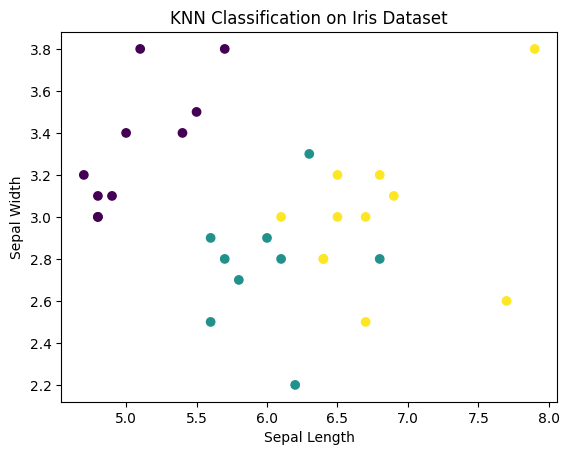

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("Iris.csv")

# Drop Id column if present
if "Id" in df.columns:
    df = df.drop("Id", axis=1)

# Features and target
X = df.drop("Species", axis=1)
y = df["Species"]

# Encode target labels
le = LabelEncoder()
y = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# KNN model
k = 5
model = KNeighborsClassifier(n_neighbors=k)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Save output to text file
with open("knn_output.txt", "w") as file:
    file.write("KNN Classification Output (Iris Dataset)\n")
    file.write("--------------------------------------\n")
    file.write(f"Value of K: {k}\n")
    file.write(f"Accuracy: {accuracy}\n\n")
    file.write("Classification Report:\n")
    file.write(classification_report(y_test, y_pred, target_names=le.classes_))

print("Output saved in knn_output.txt")

# -------- GRAPH --------
# Visualizing first two features only
plt.scatter(
    X_test.iloc[:, 0],
    X_test.iloc[:, 1],
    c=y_pred
)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("KNN Classification on Iris Dataset")

# Save graph
plt.savefig("knn_iris_graph.png")

# Show graph
plt.show()
